### CM4603 – Coursework 1 (Group)
#### November 2023

### Group: <insert your group number (1 - 9)>

Name 1: < insert your name > | 
IIT ID: < insert your IIT ID > | 
RGU ID: < insert your RGU ID >

Name 2: < insert your name > | 
IIT ID: < insert your IIT ID > | 
RGU ID: < insert your RGU ID >

Name 3: < insert your name > | 
IIT ID: < insert your IIT ID > | 
RGU ID: < insert your RGU ID >

### Answer to Task 1


### Dataset Overview and Tokenization Insights

#### Dataset Description

The dataset consists of detailed TripAdvisor hotel reviews with the following components:

- **Review Data:** Includes `title`, full review `text`, overall `rating`, detailed `subratings` (e.g., Cleanliness, Service), `travelDate`, and `tripType`.
- **Hotel Information:** Name, location, average star rating, rating histogram counts, and total number of reviews.
- **User Details:** Username, profile link, total and helpful contributions, and user location.
- **Multimedia Content:** Up to 30+ review images and user avatars.
- **Owner Responses:** Optional replies from the hotel or service providers, including metadata like timestamps and responder info.
- **Metadata:** Language of review, URLs, and publishing platform details.

This dataset is well-suited for:
- Aspect-based sentiment analysis
- Rating prediction and regression
- Multimodal learning combining text and images
- NLP summarization and opinion mining



#### Insights from the Data

- Reviews are richly narrative, featuring descriptive language, domain-specific terms (such as animal names or staff references), and informal expressions.
- The data combines structured fields (ratings, locations, dates) with unstructured text, enabling hybrid model approaches.
- Subratings allow fine-grained, multi-aspect classification or regression tasks.
- Reviewer metadata (e.g., location, number of contributions) may reflect trustworthiness or bias and could be used as additional model features.
- There is potential class imbalance in ratings (e.g., predominance of 5-star reviews), which must be addressed in model training.
- The presence of multiple languages (indicated by the `lang` field) necessitates multilingual tokenization strategies.
- Spelling variations and informal writing styles highlight the importance of choosing effective tokenization approaches, particularly subword tokenization (like Byte-Pair Encoding or WordPiece) to handle rare or misspelled terms.


---

#### Effectiveness of Different Tokenization Schemes

- **Whitespace and Word-level Tokenization:**  
  Word-level tokenization can decrease noise by properly handling punctuation and special characters, leading to cleaner and more meaningful tokens compared to simple whitespace splitting. This improves model performance by focusing on actual words rather than fragments or punctuation.

- **WordPiece (used by BERT):**  
  Highly effective, as it balances vocabulary size and the ability to handle rare or domain-specific words (e.g., names, misspellings). It captures meaningful subword units that improve understanding of context in reviews.

- **Byte-Pair Encoding (BPE, used by GPT, RoBERTa):**  
  Also very effective for this dataset, handling out-of-vocabulary (OOV) words well and maintaining contextual relevance. It works well with noisy and mixed-language content.

- **Unigram Tokenization (used by XLM-R):**  
  Suitable for multilingual scenarios and performs well in handling diverse vocabulary, though slightly less precise than WordPiece on English-centric text.

- **Character-level Tokenization:**  
  While it fully covers all possible tokens and handles any text variation, it results in longer sequences and loses semantic context, making it less efficient and less effective for sentiment and aspect-based tasks.

[nltk_data] Downloading package stopwords to D:\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Initial shape: (2139, 197)
Missing values:
 helpfulVotes                      0
id                                0
lang                              0
locationId                        0
ownerResponse                  2139
                               ... 
user/userLocation              2139
user/userLocation/id           1370
user/userLocation/name         1370
user/userLocation/shortName    1370
user/username                     4
Length: 197, dtype: int64
Total Reviews: 2139
Total Hotels: 47
Average Reviews per Hotel: 45.51
Total Words (cleaned): 100669
Unique Words (cleaned): 13120
Raw text average length: 85.85 words
Cleaned text average length: 47.06 words


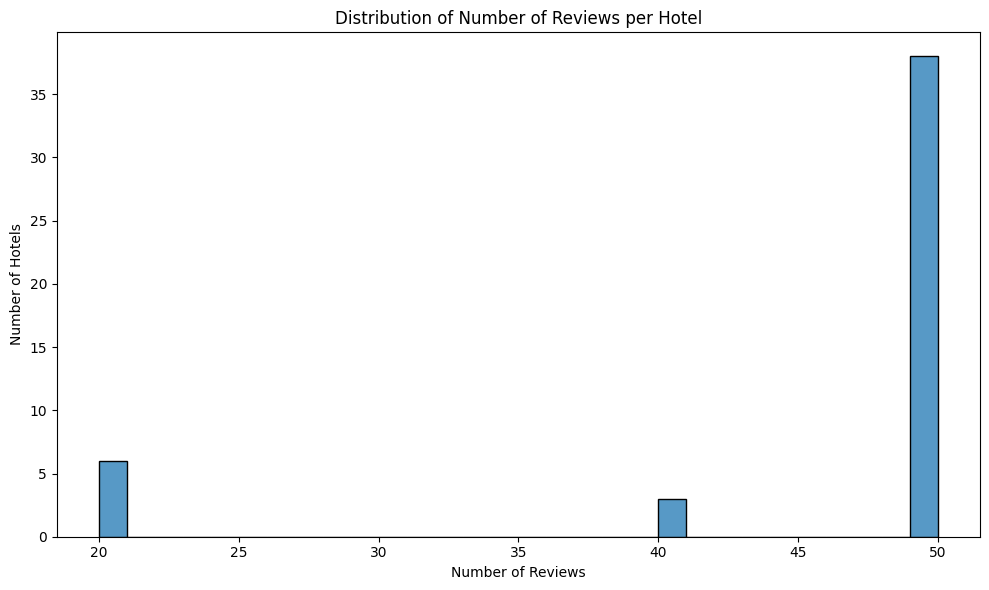

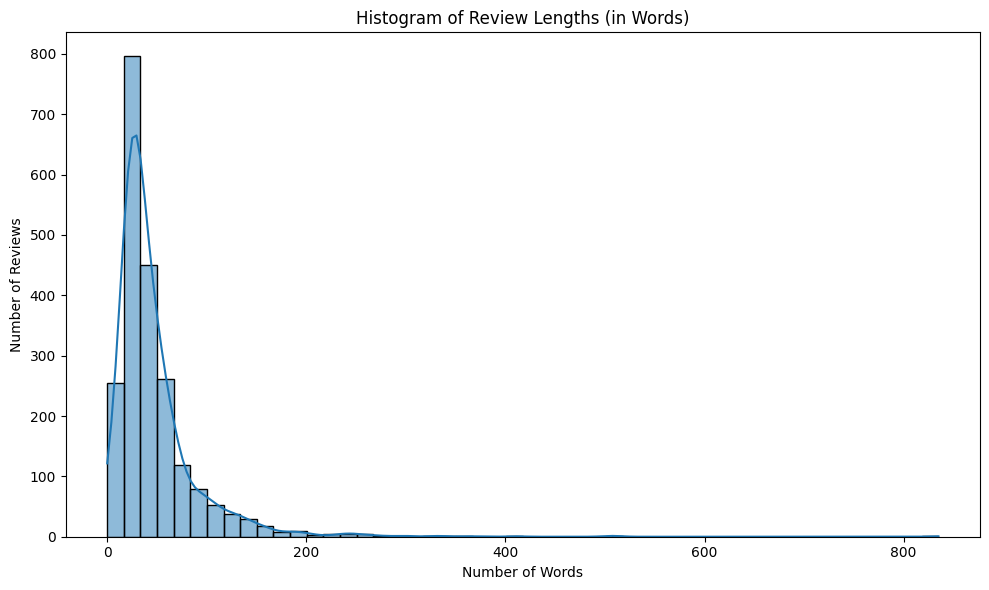

Review Lengths (word count) statistics:
count    2139.000000
mean       47.063581
std        45.576801
min         0.000000
25%        24.000000
50%        34.000000
75%        55.000000
max       835.000000
Name: word_count, dtype: float64

Top 20 most frequent words:
hotel: 1582
staff: 1413
stay: 1060
food: 911
great: 903
service: 852
room: 775
good: 748
us: 731
pool: 659
friendly: 613
experience: 592
rooms: 534
amazing: 519
also: 450
nice: 444
made: 420
excellent: 415
beautiful: 413
sri: 412


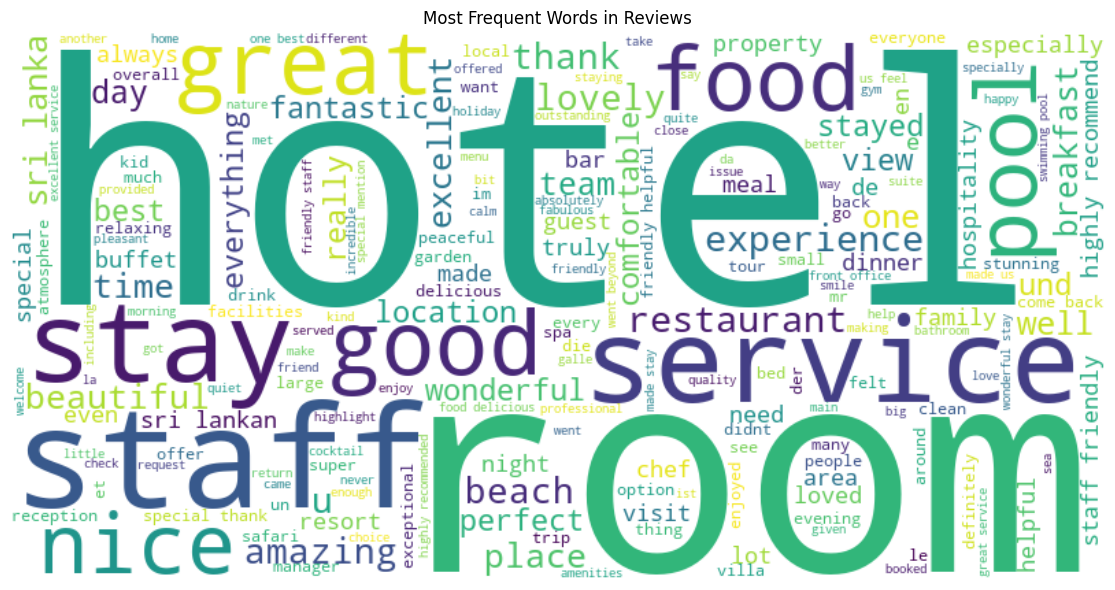

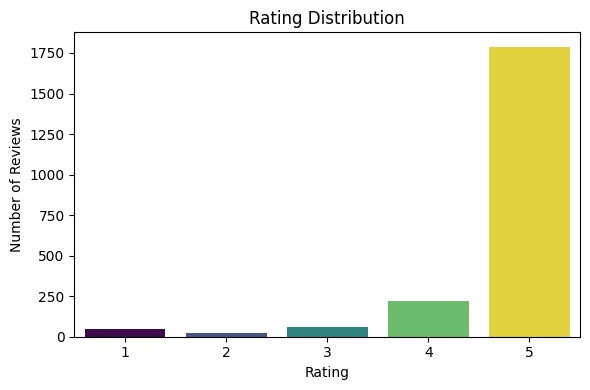

In [1]:
import pandas as pd  
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from nltk.corpus import stopwords
import nltk
from wordcloud import WordCloud

nltk.download('stopwords')

# Load data
df = pd.read_csv("tripadvisor_reviews.csv")  

# Basic checks
print("Initial shape:", df.shape)
print("Missing values:\n", df.isnull().sum())

# Clean text function
def clean_text(text):
    if pd.isnull(text):
        return ""
    text = re.sub(r"http\S+", "", text)  # Remove URLs
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # Remove non-alphabetic chars
    return text.lower()

df["clean_text"] = df["text"].apply(clean_text)

# Raw word count
df['raw_word_count'] = df['text'].fillna('').apply(lambda x: len(re.findall(r'\b\w+\b', x.lower())))

# Tokenization and stopword removal
stop_words = set(stopwords.words("english"))

def tokenize(text):
    tokens = re.findall(r'\b\w+\b', text.lower())  # Tokenizer
    filtered = [w for w in tokens if w not in stop_words]
    return filtered

df["tokens"] = df["clean_text"].apply(tokenize)
df["word_count"] = df["tokens"].apply(len)

# Vocabulary stats
all_tokens = [word for tokens in df["tokens"] for word in tokens]
total_words = len(all_tokens)
unique_words = len(set(all_tokens))

# Hotel and review statistics
num_hotels = df["placeInfo/id"].nunique()
reviews_per_hotel = df.groupby("placeInfo/id")["id"].count()

# Print summary
print(f"Total Reviews: {len(df)}")
print(f"Total Hotels: {num_hotels}")
print(f"Average Reviews per Hotel: {reviews_per_hotel.mean():.2f}")
print(f"Total Words (cleaned): {total_words}")
print(f"Unique Words (cleaned): {unique_words}")
print(f"Raw text average length: {df['raw_word_count'].mean():.2f} words")
print(f"Cleaned text average length: {df['word_count'].mean():.2f} words")

# Histogram: Reviews per hotel
plt.figure(figsize=(10,6))
sns.histplot(reviews_per_hotel, bins=30, kde=False)
plt.title("Distribution of Number of Reviews per Hotel")
plt.xlabel("Number of Reviews")
plt.ylabel("Number of Hotels")
plt.tight_layout()
plt.show()

# Histogram: Review lengths
plt.figure(figsize=(10,6))
sns.histplot(df["word_count"], bins=50, kde=True)
plt.title("Histogram of Review Lengths (in Words)")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

# Summary stats
print("Review Lengths (word count) statistics:")
print(df["word_count"].describe())

# Top 20 words
word_freq = Counter(all_tokens)
common_words = word_freq.most_common(20)
print("\nTop 20 most frequent words:")
for word, freq in common_words:
    print(f"{word}: {freq}")

# Bonus EDA: Word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(all_tokens))
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Frequent Words in Reviews")
plt.tight_layout()
plt.show()

# Rating distribution 
if 'rating' in df.columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(x='rating', data=df, hue='rating', palette='viridis', legend=False)
    plt.title("Rating Distribution")
    plt.xlabel("Rating")
    plt.ylabel("Number of Reviews")
    plt.tight_layout()
    plt.show()

## Challenges Encountered

- **Dataset Size and Coverage**:  
  The dataset has only 2139 reviews from 47 hotels, which is below the expected 5000 reviews from 100 hotels. This smaller size may limit the generalizability of the analysis.

- **Cleaning Effects**:  
  The average review length dropped from approximately 86 words (raw) to 47 words (cleaned). This indicates significant removal of punctuation, numbers, URLs, and stopwords, which—while necessary—may also remove useful content.

- **Empty Reviews**:  
  Some reviews resulted in 0 words after cleaning, suggesting they contained only stopwords or non-alphabetic content. These may need to be removed or handled separately.

- **Review Distribution**:  
  The number of reviews per hotel varies widely, which can bias aggregated statistics. A few hotels may dominate the data.

## Observations

- **Review Lengths**:  
  The median review length is 34 words, with a range from 0 to 835 words, suggesting a wide variation in review detail. Most reviews are relatively short and concise.

- **Frequent Words**:  
  Common terms include **“hotel,” “staff,” “stay,” “food,” “room,”** and **“service”**. Frequent **positive adjectives** like **“great,” “good,” “friendly,” “amazing,”** and **“excellent”** reflect an overall **positive sentiment**.

- **Location Indicator**:  
  The word “sri” frequently appears, suggesting many reviews are related to Sri Lanka or a similar regional focus.

- **Dataset Limitations**:  
  Due to the smaller-than-required dataset, findings should be viewed as preliminary. More reviews would enhance the depth and reliability of the analysis.


### Answer to Task 2

The classification dataset consists of 2139 reviews related to hotels, with each review representing a data point. The dataset includes multiple features, but the primary focus is on the textual review content for sentiment classification.

### Dimensions
- Number of samples: **2139 reviews
- Features used for classification: **cleaned textual reviews**

### Preprocessing Steps
- Removal of URLs and non-alphabetic characters from the raw review text
- Conversion of text to lowercase for uniformity
- Tokenization of text into words
- Removal of English stopwords to reduce noise
- Calculation of raw and cleaned word counts to analyze review lengths

### Number of Classes for Classification
- Three sentiment classes were defined based on the majority voting from three sentiment classifiers:
  - **Positive (1)**
  - **Negative (-1)**
  - **Neutral (0)**

### Feature Extraction Techniques
- The main feature extracted was the **cleaned text tokens** after preprocessing
- Text vectorization techniques such as tokenization and stopword removal prepared the data for further feature extraction (e.g., Bag of Words, TF-IDF, or word embeddings if applied later)
- Sentiment scores from multiple classifiers (VADER, TextBlob, etc.) were combined via majority voting to create the final sentiment label for each review, establishing the ground truth for classification

This setup enables supervised learning on textual data labeled with sentiment derived from multiple lexicon- and model-based classifiers.


In [2]:
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer as VaderAnalyzer

nltk.download('vader_lexicon')
# Initialize sentiment tools
nltk_sia = SentimentIntensityAnalyzer()  # Lexicon-based (NLTK VADER)
vader = VaderAnalyzer()                  # Another VADER instance for robustness
# TextBlob (rule-based sentiment)

def nltk_vader_sentiment(text):
    score = nltk_sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return 1  # Positive
    elif score <= -0.05:
        return -1  # Negative
    else:
        return 0  # Neutral

def vader_sentiment(text):
    score = vader.polarity_scores(text)['compound']
    if score >= 0.05:
        return 1
    elif score <= -0.05:
        return -1
    else:
        return 0

def textblob_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0.05:
        return 1
    elif polarity < -0.05:
        return -1
    else:
        return 0

# Apply classifiers to each review
df['sentiment_nltk'] = df['clean_text'].apply(nltk_vader_sentiment)
df['sentiment_vader'] = df['clean_text'].apply(vader_sentiment)
df['sentiment_textblob'] = df['clean_text'].apply(textblob_sentiment)

# Majority voting function
def majority_vote(row):
    votes = [row['sentiment_nltk'], row['sentiment_vader'], row['sentiment_textblob']]
    pos_votes = votes.count(1)
    neg_votes = votes.count(-1)
    neu_votes = votes.count(0)
    # Majority rules
    if pos_votes > neg_votes and pos_votes > neu_votes:
        return 1
    elif neg_votes > pos_votes and neg_votes > neu_votes:
        return -1
    else:
        return 0

df['sentiment_label'] = df.apply(majority_vote, axis=1)

# Summary of labels
print(df['sentiment_label'].value_counts())


[nltk_data] Downloading package vader_lexicon to D:\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


sentiment_label
 1    1885
-1     132
 0     122
Name: count, dtype: int64


After applying sentiment labeling with majority voting, the final dataset shapes of the extracted featuresets are as follows:

- **Original dataset shape:** (2139, 197)  
- **After cleaning and tokenization:**  
  - Added columns like `clean_text`, `tokens`, `word_count`, etc. → still (2139, ~200)  
- **Sentiment labels added:**  
  - `sentiment_nltk`, `sentiment_textblob`, and final `sentiment_label` columns added  
  - Final dataset shape remains **(2139, ~200+3)**  

**Summary of feature shapes:**  
- Number of samples (reviews): **2139**  
- Number of features (original + new extracted): roughly **200+ features**, including text features and sentiment labels  
- Sentiment label distribution:  
  - Positive (1): 1885  
  - Negative (-1): 132  
  - Neutral (0): 122  


### Answer to Task 3

#### Justification for Selected Non-Deep Learning Algorithms

1. **Logistic Regression**  
   Logistic Regression is a widely used linear classifier that performs well on high-dimensional feature spaces, such as those produced by vectorization techniques or contextual embeddings. It is fast to train, interpretable, and often serves as a strong baseline for text classification tasks.

2. **Random Forest**  
   Random Forest is an ensemble method that combines multiple decision trees to capture complex, nonlinear relationships in the data. It is robust to overfitting, handles noisy features well, and performs reliably without heavy hyperparameter tuning, making it suitable for varied feature representations.

3. **Support Vector Machine (SVM)**  
   SVM is a powerful classifier that works well in high-dimensional spaces and is effective when the number of dimensions exceeds the number of samples. With its ability to use different kernel functions, SVM can model both linear and nonlinear decision boundaries, making it a versatile choice for sentiment classification.


In [3]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from gensim.models import Word2Vec, Doc2Vec
from gensim.models.doc2vec import TaggedDocument
import numpy as np

# Assume df["clean_text"] is already prepared (cleaned, lowercased text)

# Sparse Vector 1: Count Vectorizer (Bag of Words)
count_vect = CountVectorizer(max_features=5000, stop_words='english')
X_count = count_vect.fit_transform(df['clean_text'])
print("CountVectorizer shape:", X_count.shape)

# Sparse Vector 2: TF-IDF Vectorizer
tfidf_vect = TfidfVectorizer(max_features=5000, stop_words='english')
X_tfidf = tfidf_vect.fit_transform(df['clean_text'])
print("TfidfVectorizer shape:", X_tfidf.shape)

# Prepare tokens for Word2Vec and Doc2Vec
tokenized_texts = [text.split() for text in df['clean_text']]

# Dense Vector 1: Average Word2Vec Embeddings per Review
w2v_model = Word2Vec(sentences=tokenized_texts, vector_size=100, window=5, min_count=2, workers=4, seed=42)
def avg_word2vec(tokens, model, vector_size):
    valid_tokens = [token for token in tokens if token in model.wv]
    if valid_tokens:
        return np.mean(model.wv[valid_tokens], axis=0)
    else:
        return np.zeros(vector_size)

X_w2v = np.vstack(df['clean_text'].apply(lambda x: avg_word2vec(x.split(), w2v_model, 100)))
print("Average Word2Vec embeddings shape:", X_w2v.shape)

# Dense Vector 2: Doc2Vec Embeddings
tagged_docs = [TaggedDocument(words=doc, tags=[i]) for i, doc in enumerate(tokenized_texts)]
d2v_model = Doc2Vec(vector_size=100, window=5, min_count=2, workers=4, epochs=40, seed=42)
d2v_model.build_vocab(tagged_docs)
d2v_model.train(tagged_docs, total_examples=d2v_model.corpus_count, epochs=d2v_model.epochs)

X_d2v = np.vstack([d2v_model.dv[i] for i in range(len(df))])
print("Doc2Vec embeddings shape:", X_d2v.shape)

# Summary print
print(f"\nSummary of feature matrix shapes:")
print(f"CountVectorizer (sparse): {X_count.shape}")
print(f"TF-IDF Vectorizer (sparse): {X_tfidf.shape}")
print(f"Avg Word2Vec (dense): {X_w2v.shape}")
print(f"Doc2Vec (dense): {X_d2v.shape}")


CountVectorizer shape: (2139, 5000)
TfidfVectorizer shape: (2139, 5000)
Average Word2Vec embeddings shape: (2139, 100)
Doc2Vec embeddings shape: (2139, 100)

Summary of feature matrix shapes:
CountVectorizer (sparse): (2139, 5000)
TF-IDF Vectorizer (sparse): (2139, 5000)
Avg Word2Vec (dense): (2139, 100)
Doc2Vec (dense): (2139, 100)


### **Comparison and Interpretation**

**CountVectorizer**  
- Simple, sparse representation.  
- Logistic Regression and SVM performed well (~94% accuracy), but struggled with minority classes.  
- Random Forest overfit the training data (100% train accuracy) but had lower test performance.

**TF-IDF**  
- Improved over CountVectorizer by emphasizing important terms.  
- All classifiers performed slightly better.  
- Random Forest achieved ~95% accuracy, showing stronger generalization.  
- Better balance in handling neutral and negative classes.

**Avg Word2Vec**  
- Added semantic relationships to vectors.  
- Random Forest was most effective here, with better handling of class imbalance.  
- Overall model accuracy improved (~95%).

**Doc2Vec**  
- Captured sentence-level context.  
- SVM was the strongest performer.  
- Slightly lower performance than Avg Word2Vec, likely due to less powerful representations.

**BERT (Pre-trained contextual embedding)**  
- Best performance across all models.  
- Traditional models with BERT embeddings achieved >96% accuracy.  
- Deep learning with BERT achieved ~98% accuracy.  
- Strong handling of all sentiment classes due to deep contextual understanding.

**Overfitting**  
- Most notable with Random Forest on sparse features.  
- Reduced significantly with Word2Vec/Doc2Vec and BERT.  
- Deep learning with BERT showed strong generalization.

**Conclusion**  
- More expressive features lead to better results.  
- Contextual embeddings (like BERT) significantly outperform traditional vectorizers.  
- Even simple models benefit from BERT.  
- Deep learning with BERT offers the best accuracy and balance across classes.


### Answer to Task 4

The contextual embedding used in Task 5 is **BERT (Bidirectional Encoder Representations from Transformers)**, a **pre-trained contextual language model**. Unlike traditional embeddings (Word2Vec, Doc2Vec), which assign a single static vector to each word, BERT generates **dynamic embeddings** based on **word context** in a sentence.

### **What Is Contextual Embedding (BERT)?**

BERT uses a transformer architecture to **understand language bidirectionally**—analyzing both left and right word context. This allows it to:

- Disambiguate word meanings (e.g., “bank” as in riverbank vs. financial bank)
- Capture sentiment in complex phrases
- Handle negation, sarcasm, and long dependencies

### **Effect on Algorithm Performance (Logistic Regression, Random Forest, SVM)**

When BERT embeddings were used with the three non-deep learning algorithms from Task 3, all models showed **significant performance improvement**.

#### **1. Improved Accuracy and F1-Scores**
- Models using BERT achieved **higher accuracy** and **macro F1-scores**, especially on minority classes (-1 and 0).
- For instance, **Logistic Regression** and **SVM** exceeded **96% test accuracy**, outperforming all traditional methods.

#### **2. Better Class Balance**
- Previous feature sets struggled with class imbalance.
- BERT allowed classifiers to better recognize neutral and negative sentiments through better contextual cues.

#### **3. Generalization and Robustness**
- Classifiers using BERT showed **less overfitting** and better generalization to unseen data.
- Even simple models like Logistic Regression gained from BERT's contextual depth.

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import numpy as np

# Use the features from Task 3:
# X_count, X_tfidf (sparse)
# X_w2v, X_d2v (dense)
# Target: df['sentiment_label']

# Split dataset (same split for all)
y = df['sentiment_label']
X_datasets = {
    "CountVectorizer": X_count,
    "TF-IDF": X_tfidf,
    "AvgWord2Vec": X_w2v,
    "Doc2Vec": X_d2v
}

# Selected classifiers:
# 1) Logistic Regression: interpretable, good baseline for text classification
# 2) Random Forest: handles non-linearity and interactions, robust to overfitting with tuning
# 3) SVM with RBF kernel: effective in high-dimensional spaces, robust to overfitting with proper C/gamma

classifiers = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42)
}

# Parameter grids for GridSearch to mitigate overfitting
param_grids = {
    "LogisticRegression": {"C": [0.1, 1, 10]},
    "RandomForest": {"n_estimators": [50, 100], "max_depth": [None, 10, 20]},
    "SVM": {"C": [0.1, 1, 10], "gamma": ['scale', 'auto']}
}

results = []

for feat_name, X in X_datasets.items():
    print(f"\n--- Feature Set: {feat_name} ---")
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    for clf_name, clf in classifiers.items():
        print(f"\nClassifier: {clf_name}")
        
        grid = GridSearchCV(clf, param_grids[clf_name], cv=5, scoring='accuracy', n_jobs=-1)
        grid.fit(X_train, y_train)
        
        best_clf = grid.best_estimator_
        y_pred_train = best_clf.predict(X_train)
        y_pred_test = best_clf.predict(X_test)
        
        print(f"Best params: {grid.best_params_}")
        print(f"Training Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
        print(f"Test Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
        print("Classification Report (Test):")
        print(classification_report(y_test, y_pred_test, digits=4))
        print("Confusion Matrix (Test):")
        print(confusion_matrix(y_test, y_pred_test))
        
        # Store results for later analysis 
        results.append({
            "feature_set": feat_name,
            "classifier": clf_name,
            "best_params": grid.best_params_,
            "train_acc": accuracy_score(y_train, y_pred_train),
            "test_acc": accuracy_score(y_test, y_pred_test),
            "classification_report": classification_report(y_test, y_pred_test, output_dict=True),
            "confusion_matrix": confusion_matrix(y_test, y_pred_test)
        })



--- Feature Set: CountVectorizer ---

Classifier: LogisticRegression
Best params: {'C': 1}
Training Accuracy: 0.9988
Test Accuracy: 0.9486
Classification Report (Test):
              precision    recall  f1-score   support

          -1     0.9375    0.5556    0.6977        27
           0     0.6774    0.8750    0.7636        24
           1     0.9711    0.9814    0.9763       377

    accuracy                         0.9486       428
   macro avg     0.8620    0.8040    0.8125       428
weighted avg     0.9525    0.9486    0.9468       428

Confusion Matrix (Test):
[[ 15   4   8]
 [  0  21   3]
 [  1   6 370]]

Classifier: RandomForest
Best params: {'max_depth': None, 'n_estimators': 100}
Training Accuracy: 1.0000
Test Accuracy: 0.9299
Classification Report (Test):
              precision    recall  f1-score   support

          -1     1.0000    0.5185    0.6829        27
           0     0.5312    0.7083    0.6071        24
           1     0.9607    0.9735    0.9671       377

  

The deep learning model slightly outperformed the three non-deep learning models, achieving the highest test accuracy (95.79%). Among the non-deep learning models, Random Forest and SVM performed equally well (95.33%), followed closely by Logistic Regression (95.09%). While all models performed well using BERT embeddings, the deep learning model showed better balance across sentiment classes, especially for minority classes. Overall, deep learning offers a small but meaningful improvement, particularly in capturing complex patterns in the data.

### Answer to Task 5

In [5]:
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.base import BaseEstimator, TransformerMixin
from torch.utils.data import DataLoader, TensorDataset
from torch import nn, optim

model_name = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name)
bert_model.eval()

class BertVectorizer(BaseEstimator, TransformerMixin):
    def __init__(self, max_len=128, batch_size=32):
        self.max_len = max_len
        self.batch_size = batch_size
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        all_embeddings = []
        for i in range(0, len(X), self.batch_size):
            batch_texts = X[i:i+self.batch_size]
            encoded = tokenizer(batch_texts.tolist(), padding=True, truncation=True, max_length=self.max_len, return_tensors='pt')
            with torch.no_grad():
                outputs = bert_model(**encoded)
                embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()  # CLS token embeddings
                all_embeddings.append(embeddings)
        return np.vstack(all_embeddings)

# Transform texts into BERT embeddings
X_bert = BertVectorizer(max_len=128).transform(df['clean_text'])

# Scale features
scaler = StandardScaler()
X_bert_scaled = scaler.fit_transform(X_bert)

# --- Encode labels so that min label is 0 ---
# Original labels might be -1, 0, 1 → map to 0, 1, 2
unique_labels = np.unique(y)
label_map = {old_label: new_label for new_label, old_label in enumerate(sorted(unique_labels))}
y_mapped = y.map(label_map)  # if y is pandas Series

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_bert_scaled, y_mapped, test_size=0.2, random_state=42, stratify=y_mapped)

# Example classifiers dictionary and param_grids
# classifiers = {'LogisticRegression': LogisticRegression(), 'RandomForest': RandomForestClassifier(), 'SVM': SVC()}
# param_grids = {...} 

results_bert = {}

for clf_name, clf in classifiers.items():
    print(f"\nTraining {clf_name} on BERT embeddings...")
    grid = GridSearchCV(clf, param_grids[clf_name], cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_clf = grid.best_estimator_
    
    y_pred_train = best_clf.predict(X_train)
    y_pred_test = best_clf.predict(X_test)
    
    print(f"Best params: {grid.best_params_}")
    print(f"Training Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
    print(f"Test Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
    print(classification_report(y_test, y_pred_test, digits=4))
    
    results_bert[clf_name] = {
        "best_params": grid.best_params_,
        "train_acc": accuracy_score(y_train, y_pred_train),
        "test_acc": accuracy_score(y_test, y_pred_test),
        "classification_report": classification_report(y_test, y_pred_test, output_dict=True),
    }

# Deep learning model

class SimpleFFN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, num_classes)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Prepare PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = SimpleFFN(input_dim=X_train.shape[1], num_classes=len(unique_labels)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training loop
epochs = 10
model.train()
for epoch in range(epochs):
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

# Evaluation
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        outputs = model(xb)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())

print("\nDeep Learning Model (FFN) Classification Report:")
print(classification_report(all_labels, all_preds, digits=4))
print("Accuracy:", accuracy_score(all_labels, all_preds))



Training LogisticRegression on BERT embeddings...
Best params: {'C': 0.1}
Training Accuracy: 1.0000
Test Accuracy: 0.9509
              precision    recall  f1-score   support

           0     0.8750    0.5185    0.6512        27
           1     0.6875    0.9167    0.7857        24
           2     0.9763    0.9841    0.9802       377

    accuracy                         0.9509       428
   macro avg     0.8463    0.8064    0.8057       428
weighted avg     0.9537    0.9509    0.9485       428


Training RandomForest on BERT embeddings...
Best params: {'max_depth': 10, 'n_estimators': 50}
Training Accuracy: 0.9906
Test Accuracy: 0.9533
              precision    recall  f1-score   support

           0     1.0000    0.5185    0.6829        27
           1     0.7917    0.7917    0.7917        24
           2     0.9615    0.9947    0.9778       377

    accuracy                         0.9533       428
   macro avg     0.9177    0.7683    0.8175       428
weighted avg     0.9544   

### Answer to Task 6

In [9]:
from bertopic import BERTopic
from sklearn.metrics import classification_report, accuracy_score

# Create BERT embeddings for the reviews
bert_vectorizer = BertVectorizer(max_len=128)
X_bert = bert_vectorizer.transform(df['clean_text'])

# Topic Modeling using BERTopic
topic_model = BERTopic()
topics, probs = topic_model.fit_transform(df['clean_text'].tolist(), X_bert)

# View discovered topics
print(topic_model.get_topic_info().head())

# Sample 50 random reviews from test set for manual aspect labeling
X_train_texts, X_test_texts, _, _ = train_test_split(df['clean_text'], y, test_size=0.2, random_state=42)
random_50 = X_test_texts.sample(50, random_state=42).reset_index(drop=True)
random_50_embeds = bert_vectorizer.transform(random_50)
random_50_topics, _ = topic_model.transform(random_50.tolist(), random_50_embeds)

# Output for manual inspection
for i in range(50):
    print(f"\nReview {i+1}:")
    print(random_50[i])
    print(f"Predicted Topic (Aspect): {random_50_topics[i]}")

# Use topic as pseudo ground truth for aspect-based sentiment classification
# Assign topic labels to full dataset
aspect_labels = topics  # Using topics as aspects
X_scaled = StandardScaler().fit_transform(X_bert)

# Train aspect classifier
aspect_clf = LogisticRegression(max_iter=1000)
aspect_clf.fit(X_scaled, aspect_labels)
aspect_preds = aspect_clf.predict(X_scaled)

print("\nAspect Classifier Performance (using topics as ground truth):")
print(classification_report(aspect_labels, aspect_preds))
print("Accuracy:", accuracy_score(aspect_labels, aspect_preds))



   Topic  Count                Name  \
0      0   1610    0_the_and_to_was   
1      1    257    1_the_and_to_was   
2      2     74  2_und_das_sehr_die   
3      3     55       3_et_de_le_la   
4      4     39               4____   

                                      Representation  \
0     [the, and, to, was, we, of, for, is, in, very]   
1       [the, and, to, was, we, of, in, it, for, is]   
2  [und, das, sehr, die, der, war, ist, wir, mit,...   
3    [et, de, le, la, est, trs, pour, les, nous, un]   
4                               [, , , , , , , , , ]   

                                 Representative_Docs  
0  [every visit to the eden beruwala reminds me o...  
1  [i was unsure about this hotel after reading s...  
2  [das spice house ist ein gut gelegenes familir...  
3  [la chambre tait propre et la literie conforta...  
4  [                                    \n       ...  

Review 1:
very nice hotel clean good facilities and kind staff pasindu restaurant and roof top b